In [5]:
python -m pip install numpy scipy xarray dask h5py numba pyfftw tqdm
python -m pip install matplotlib ipympl ipywidgets
python -m pip install plotly kaleido
pip install scikit-image colorcet

Unrecognized function or variable 'python'.

In [ ]:
3D Plotting and Isosurfaces

In [ ]:
python -m pip install pyvista vtk

In [ ]:
Clean UI

In [ ]:
python -m pip install jupyterlab-lsp python-lsp-server jupyterlab-code-formatter black isort jupytext nbstripout


In [2]:
%matplotlib widget  # interactive figures in JupyterLab

from pathlib import Path
import numpy as np, xarray as xr, matplotlib.pyplot as plt
import ipywidgets as w
import plotly.graph_objects as go

Invalid expression. Check for missing multiplication operator, missing or unbalanced delimiters, or other syntax error. To construct matrices, use brackets instead of parentheses.

In [ ]:
%Backprojection reconstruction

Reconstruction Starting
Image 1/25 Processed
Image 2/25 Processed
Image 3/25 Processed
Image 4/25 Processed
Image 5/25 Processed
Image 6/25 Processed
Image 7/25 Processed
Image 8/25 Processed
Image 9/25 Processed
Image 10/25 Processed
Image 11/25 Processed
Image 12/25 Processed
Image 13/25 Processed
Image 14/25 Processed
Image 15/25 Processed
Image 16/25 Processed
Image 17/25 Processed
Image 18/25 Processed
Image 19/25 Processed
Image 20/25 Processed
Image 21/25 Processed
Image 22/25 Processed
Image 23/25 Processed
Image 24/25 Processed
Image 25/25 Processed


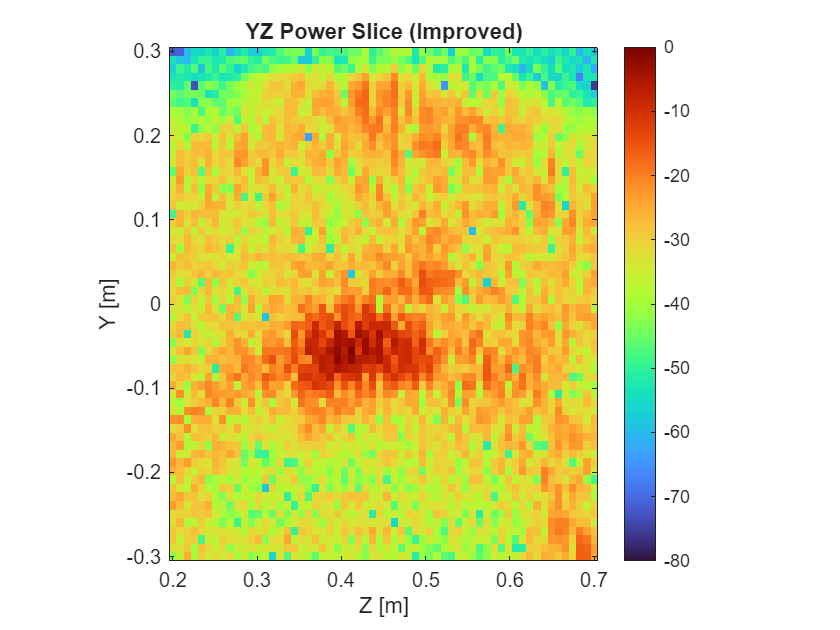

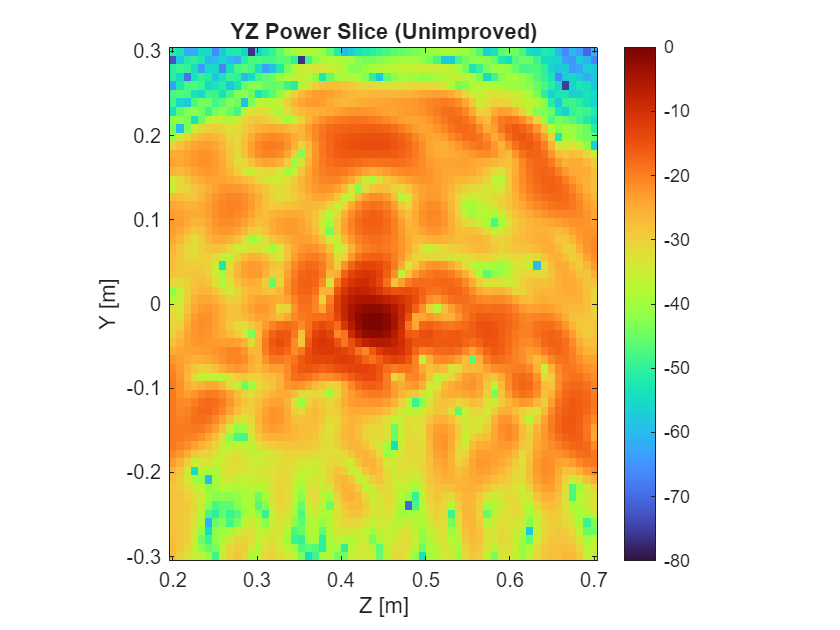

Elapsed time is 178.671848 seconds.


In [1]:
% y axis - horizontal printer move
% x axis - vetical printer move
% z axis - towards target

% Backprojection based off of grid center (assume NxN square grid)
%close all; clc; clear;

%% ---------------- USER PARAMS ----------------------------------------

close all; clear; disp('Reconstruction Starting'); tic;

%% ---------------- USER PARAMS ----------------------------------------
dataFile = 'YZ_2D_20250811_204940.mat';
load(dataFile)   % contains variable `recs`
[~, baseName] = fileparts(dataFile);

vtrigU_ants_location;
[Xgrid,Ygrid,Zgrid]=meshgrid(xgrid,ygrid,zgrid);

src = reshape(cat(4,Xgrid,Ygrid,Zgrid),[],3);
src2 = permute(src,[3,2,4,1]);
c = physconst('lightspeed'); %(m/s)
N_freq = length(freq);
Nfft = 2^(ceil(log2(size(freq,2)))+1);

%% dynamic grid collapse (collapse the smallest axis) ----
% lengths of each axis
lens = [numel(xgrid), numel(ygrid), numel(zgrid)];  
% pick the axis with the fewest samples
[~, sliceDim] = min(lens);            

% collapse that axis to its first value
gv = {xgrid, ygrid, zgrid};
gv{sliceDim} = gv{sliceDim}(1);       
[xgrid, ygrid, zgrid] = deal(gv{:});

% determine which two axes remain for rows/cols
denseDims = setdiff(1:3, sliceDim);  
gridA     = gv{denseDims(1)};  % rows
gridB     = gv{denseDims(2)};  % cols
Ny = numel(xgrid);
Nx = numel(ygrid);
Nz = numel(zgrid);

% % NxN=5; xstep=40; zstep=40; gridCenter=[150,150]; 
% % 
% % printer_positions=zeros(NxN^2,2);printer_offsets = zeros(NxN^2,2); ctr=ceil(NxN/2); idx=1;
% % for row=1:NxN
% %     z_off=(row-ctr)*zstep;
% %     cols = (mod(row,2)==1)*(1:NxN) + (mod(row,2)==0)*(NxN:-1:1);
% %     for col=cols
% %         x_off=(col-ctr)*xstep;
% %         printer_positions(idx,:) = gridCenter+[x_off z_off];
% %         printer_offsets(idx,:)   = [x_off z_off];   
% %         idx=idx+1;
% %     end
% % end

%% pre‑allocate reconstruction stack -------------
nRecs   = size(recs,3);                 % how many sweeps in .mat
y_accum = zeros( numel(gridA), numel(gridB), 'single');   % or 'double'
y_cart_sum = zeros( numel(gridA), numel(gridB), 'single');
toDB = @(M) 20*log10(abs(M)+eps) - max(20*log10(abs(M(:))+eps)); %db helper function


%% Back Projection Loop --------------------------
for i=1:nRecs
X = recs(:,:,i);
Rvec = src2-(VtrigU_ants_location + [printer_offsets(i,1) printer_offsets(i,2) 0]); %printer_offsets..  y(R->L) x(up) from vtrigU
Rmag = rssq(Rvec,2);
Rtheta = atan2(rssq(Rvec(:,1:2,:,:),2),Rvec(:,3,:,:));
Rphi = atan2(Rvec(:,2,:,:),Rvec(:,1,:,:));
Sphase = 2*pi*Rmag.*freq/c; %Electrical Length in Radians
RCS = 1; %m^2
lambda = c./freq; csf = sqrt(RCS).*lambda./((4*pi).^(3/2));
Smag = 10^(5.8/20)*RadiationPattern(Rtheta,Rphi)./Rmag;

% beam steering matrix
H2 = zeros(length(TxRxPairs),length(freq),1,length(src2));
for ii = 1:length(TxRxPairs)
    tx = TxRxPairs(ii,1); rx = TxRxPairs(ii,2);
    H2(ii,:,:,:) = 1./(csf.*Smag(tx,:,:,:).*Smag(rx,:,:,:).*...
              exp(-1j.*(Sphase(tx,:,:,:)+Sphase(rx,:,:,:))));
end
H2 = reshape(permute(H2,[4,1,2,3]),length(src2),[]); %xyz x txrx x freq

% Identify resonant frequencies 
thresh = 3;
lnconv = min(max(floor(N_freq/8)*2+1,floor(50/(freq(2)-freq(1)))*2+1),...
         floor(3*N_freq/8)*2+1); %conv length between 1/4 and 3/4 N_freq
c2 = -ones(lnconv,1)/(lnconv-1);
c2((lnconv+1)/2) = 1;
padsig = 20*log10(rssq(X,2)); %[N_freq 1]
padsig = padsig(:).';                 % ensure row
k = (lnconv-1)/2;
padsig = padarray(padsig, [0 k], 'symmetric', 'both');
padsig = conv(padsig, c2, 'valid');

f_res = padsig > thresh; % 1 x N_Freq

%Remove resonant frequencies
X = X .* (1-f_res(:));  
%convert to complex time domain signal
x = ifft(X,Nfft,2);
       
% H2: [Nvox × (Npairs*N_freq)]
Xvec = reshape(X, [], 1);         % [(N_freq*Npairs) × 1]
y_cart = H2 * Xvec;               % [Nvox × 1]
y_cart = reshape(y_cart, size(squeeze(Xgrid))); % → [Ny × Nx × Nz]
% pull out the slice (will be linear if one dim was collapsed)
temp_y = squeeze(y_cart);    % → [Ny×Nx] matrix every time

% now safe to accumulate

y_accum(:,:,i) = temp_y;
y_cart_sum = y_cart_sum + temp_y; % accumulate for reconstruction

%[m,~] = cfar2d_localmax(temp_y, 1, 6, 1e-4, 1);
%y_accum(:,:,i) = temp_y .* m; 
fprintf(1,'Image %d/%d Processed\n', i, numel(recs(1,1,:)));
pause(0.01)

end %% End of Backprojection
%% decide which plane we have --------------------
axisLabels = 'XYZ';            % 1:X  2:Y  3:Z

if     numel(xgrid) <= 10
        sliceName = 'YZ';  rows = ygrid; cols = zgrid;
elseif numel(ygrid) <= 10
        sliceName = 'XZ';  rows = xgrid; cols = zgrid;
else
        sliceName = 'XY';  rows = xgrid; cols = ygrid;

        sliceName = 'YX';  rows = xgrid; cols = ygrid;
end

%% Improved Image -------------------------------------------
C_imp = y_cart_sum;     % or rssq(y_accum,3) for RSS average
Norm_C_imp = C_imp ./ max(abs(C_imp(:)));
plotSlice(Norm_C_imp, rows, cols, sliceName, 'Improved', baseName)

%% Unimproved (first record) ---------------------------------
C_raw = squeeze(y_accum(:,:,ceil(nRecs/2) ) ); %return grid center image
Norm_C_raw = C_raw ./ max(abs(C_raw(:)));
plotSlice(Norm_C_raw, rows, cols, sliceName, 'Unimproved', baseName)

% rows, cols, sliceName already set by your if/elseif block
% for i = 1:nRecs:1
%    Temp_C = y_accum(:,:,i);
%    Normalize_C = Temp_C ./ max(abs(Temp_C(:)));
%    C_dB = 20*log10(abs(Normalize_C) + eps); 
%    C_all(:,:,i) = Normalize_C;
% end
% hFig = plotSlicesGridByPlane(stack_db, rows, cols, sliceName, ...
       % struct('Title',"All slices", 'Scale',"db"));


%% Helper Functions

function plotSlice(C, rows, cols, sliceName, tag, baseName)
    % ensure we’re working with a 2‑D slice
    C2 = squeeze(C);                        
    assert(ndims(C2)==2, 'plotSlice: expected 2‑D input, got %d‑D', ndims(C2));

    % convert to dB
    Cdb = 20*log10(abs(C2) + eps);

    figure
    % swap rows/cols via permute instead of .' on an N‑D
    imagesc(cols, rows, permute(Cdb, [2,1]))
    axis xy equal tight
    colormap turbo; colorbar

    % (the rest stays the same…)
    lim = caxis; lim(1)=floor(lim(1)/5)*5; lim(2)=ceil(lim(2)/5)*5;
    caxis(lim)
    xlabel(sprintf('%c [m]', sliceName(2)))
    ylabel(sprintf('%c [m]', sliceName(1)))
    title(sprintf('%s Power Slice (%s)', sliceName, tag))

    outFile = sprintf('%s_%s_%s.png', baseName, sliceName, tag);
    %exportgraphics(gcf, outFile, 'Resolution', 300)
end

toc



In [2]:
%check size befor pass data to python for plotting
size(y_accum)
class(y_accum)


ans = 1×3 double
    60    60    25

ans = 'single'

In [2]:
save('shared.mat','y_accum','Xgrid','Ygrid','Zgrid');   % v7 MAT, fine for <2 GB
